In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [92]:
data = pd.read_csv ("city_day.csv")
print (data.shape)

(29531, 16)


In [93]:
data.head()  #Shows first 5 rows from head.

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [94]:
print(data.columns, "\n")
#print(data.dtypes, "\n")
print(data.isnull().sum())

#print(data.isnull().sum()) counts how many missing values exist in each column.
#Real world data is always messy — some readings will be missing

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket'],
      dtype='object') 

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64


In [95]:
#Data Cleaning

data = data.dropna(subset = ["AQI"])
print (data.shape)

#Here we are droping the NA values from the specific column AQI.
#Since we only want AQI values for this project we are not going to clean other columns.
#Libraries like numpy and pandas will automatically skip NA values from other columns

(24850, 16)


In [96]:
#Finding which city has the most data

city_counts = data["City"].value_counts()
print(city_counts)

# data["City"] is only selecting City column
#value_counts counts how many rows exist for each city.
#This tells you which cities have the most recorded days of data

City
Delhi                 1999
Bengaluru             1910
Lucknow               1893
Chennai               1884
Hyderabad             1880
Patna                 1459
Gurugram              1453
Ahmedabad             1334
Visakhapatnam         1171
Amritsar              1126
Jaipur                1094
Thiruvananthapuram    1052
Amaravati              841
Mumbai                 775
Jorapokhar             771
Kolkata                754
Brajrajnagar           713
Talcher                698
Guwahati               495
Coimbatore             344
Chandigarh             299
Bhopal                 278
Shillong               205
Kochi                  158
Ernakulam              153
Aizawl                 111
Name: count, dtype: int64


In [97]:
#Now take 5 major cities in india for our calculations.
#Creating list of 5 major cities.

cities = ["Delhi", "Mumbai", "Bengaluru", "Chennai", "Kolkata"]

In [98]:
#Now create new dataset by filtering out all rows which do not belong to these cities.
#And only take rows i.e. data from these cities.

data_filtered = data[data["City"].isin(cities)]
print (data_filtered.shape, "\n")
data_filtered

#Here 'isin()' is the function in the pandas library.


(7322, 16) 



,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
4373,Bengaluru,2015-03-21,48.59,NaN,3.47,27.00,18.04,28.02,3.89,1.94,52.96,21.33,196.72,NaN,91.0,Satisfactory
4374,Bengaluru,2015-03-22,47.38,NaN,2.84,22.39,15.33,23.19,11.29,2.05,71.85,14.97,138.20,NaN,120.0,Moderate
4375,Bengaluru,2015-03-23,65.65,NaN,3.10,26.35,17.45,27.76,9.95,6.30,72.84,9.88,100.77,NaN,154.0,Moderate
4376,Bengaluru,2015-03-24,60.47,NaN,5.39,29.87,20.88,35.10,1.46,6.07,64.12,5.90,61.48,NaN,119.0,Moderate
4377,Bengaluru,2015-03-25,62.56,NaN,3.16,23.57,16.39,27.13,10.05,4.98,82.34,4.53,39.99,NaN,232.0,Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23859,Mumbai,2020-06-27,18.04,63.72,28.29,8.58,36.07,26.69,0.43,10.36,5.68,0.82,NaN,NaN,64.0,Satisfactory
23860,Mumbai,2020-06-28,12.33,44.84,27.15,8.06,34.78,26.50,0.38,10.58,5.76,0.85,NaN,NaN,64.0,Satisfactory
23861,Mumbai,2020-06-29,7.88,27.51,26.58,7.94,34.42,23.94,0.38,11.11,5.84,0.47,NaN,NaN,54.0,Satisfactory
23862,Mumbai,2020-06-30,4.66,13.87,25.25,8.02,33.25,19.89,0.36,13.40,6.94,0.73,NaN,NaN,54.0,Satisfactory


In [99]:
#Average AQI per city.

group_city = data_filtered.groupby("City")["AQI"]
avg_aqi = group_city.mean()
print (avg_aqi)

#Here "groupby()" is the pandas function.
#groupby() function make a group or array of AQI values of a particular city.


City
Bengaluru     94.318325
Chennai      114.502654
Delhi        259.487744
Kolkata      140.566313
Mumbai       105.352258
Name: AQI, dtype: float64


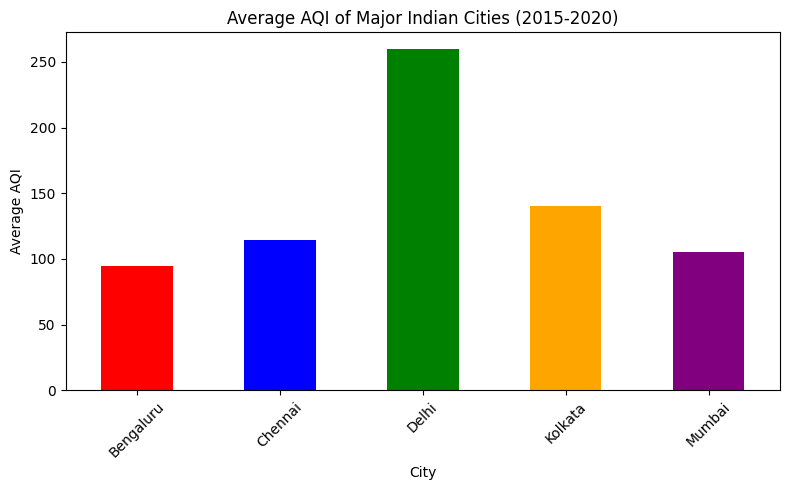

In [100]:
plt.figure(figsize = (8, 5)) #Setting the size of the plot
avg_aqi.plot(kind = "bar", color = ["red", "blue", "green", "orange", "purple"])
plt.title ("Average AQI of Major Indian Cities (2015-2020)")
plt.xlabel ("City")
plt.ylabel("Average AQI")
plt.xticks (rotation = 45)  #rotate the x axis names by 45° to avoid overlap.
plt.tight_layout()  #auto-adjusts spacing so nothing gets cut off
plt.show()

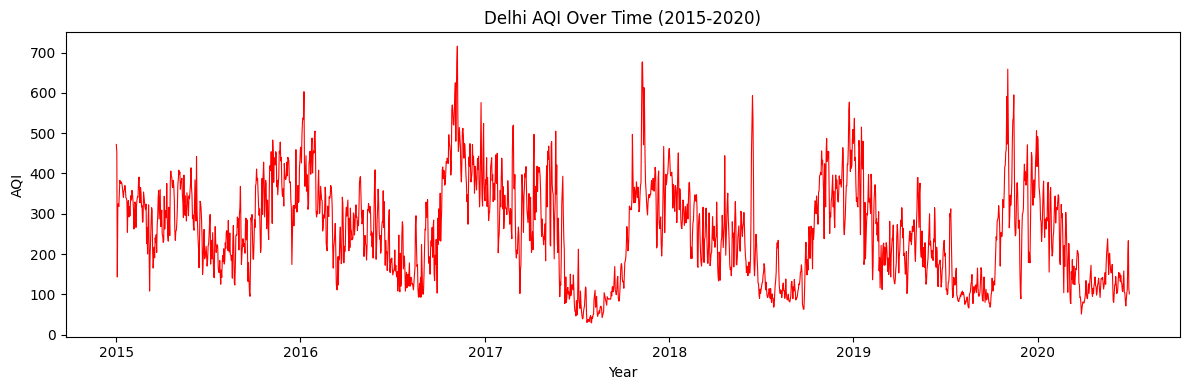

In [101]:
#Take only Delhi rows data
a1 = data_filtered[data_filtered["City"] == "Delhi"]

#Make a copy of the data so we dont modify original data
delhi_data = a1.copy()

#Now converts the Date column from plain text into actual date format Python understands
delhi_data["Date"] = pd.to_datetime(delhi_data["Date"])

#Arrange rows in chronological order (oldest to newest)
delhi_data = delhi_data.sort_values("Date")

plt.figure(figsize=(12, 4))
plt.plot(delhi_data["Date"], delhi_data["AQI"], color="red", linewidth=0.8)
plt.title("Delhi AQI Over Time (2015-2020)")
plt.xlabel("Year")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()

In [102]:

#avg_aqi.max()   gives you the NUMBER
#avg_aqi.idxmax()  gives you the CITY NAME

most_polluted = avg_aqi.idxmax()
least_polluted = avg_aqi.idxmin()

print(f"Most polluted city: {most_polluted} with AQI {avg_aqi.max():.2f}")
print(f"Least polluted city: {least_polluted} with AQI {avg_aqi.min():.2f}")

#"f" - this is called an f-string. It lets you put variable values directly inside a sentence using {}
#".2f" — formats the number to 2 decimal places

Most polluted city: Delhi with AQI 259.49
Least polluted city: Bengaluru with AQI 94.32


In [103]:
#AQI Category Distribution for Delhi

#Define a new function

def categorize_aqi (aqi):
  if aqi <= 50:
    return "Good"
  elif aqi <= 100:
    return "Satisfactory"
  elif aqi <= 200:
    return "Moderate"
  elif aqi <= 300:
    return "Poor"
  elif aqi <= 400:
    return "Very Poor"
  else:
   return "Severe"

#The function is defined

In [104]:
delhi_data["AQI_Category"] = delhi_data["AQI"].apply(categorize_aqi)

#The right side produces a new column of results of AQI Categories:
#Moderate, Satisfactory, gGood, Severe....
#And we are assinging this column to a new column named "AQI Category"


In [105]:
category_counts = delhi_data["AQI_Category"].value_counts()
print (category_counts)

AQI_Category
Poor            542
Very Poor       520
Moderate        519
Severe          239
Satisfactory    158
Good             21
Name: count, dtype: int64


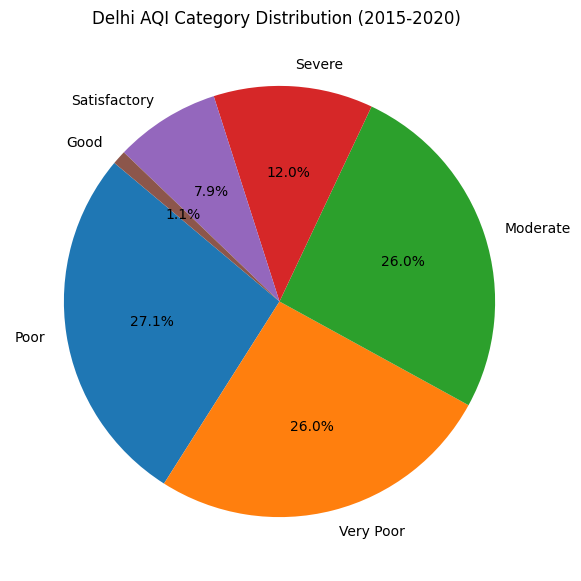

In [106]:
plt.figure(figsize = (7, 7))
plt.pie (category_counts, labels = category_counts.index, autopct = "%1.1f%%", startangle = 140 )
plt.title ("Delhi AQI Category Distribution (2015-2020) ")
plt.show()